## EDA of Nashville Music Venues 2013-2019

### Basic EDA

Shape: (12350, 15)
Unique review_id: 12350
Unique business_id: 139
Unique user_id: 9724
Date range: 2013-01-01 03:26:14 to 2019-12-31 23:49:00

Top missingness (%):
review_id       0.0
user_id         0.0
business_id     0.0
name            0.0
postal_code     0.0
latitude        0.0
longitude       0.0
review_count    0.0
date            0.0
year            0.0
dtype: float64

Duplicate rows: 0
Duplicate review_id: 0

Stars distribution:
       count    pct
stars              
1.0     1525  12.35
2.0      967   7.83
3.0     1470  11.90
4.0     3198  25.89
5.0     5190  42.02


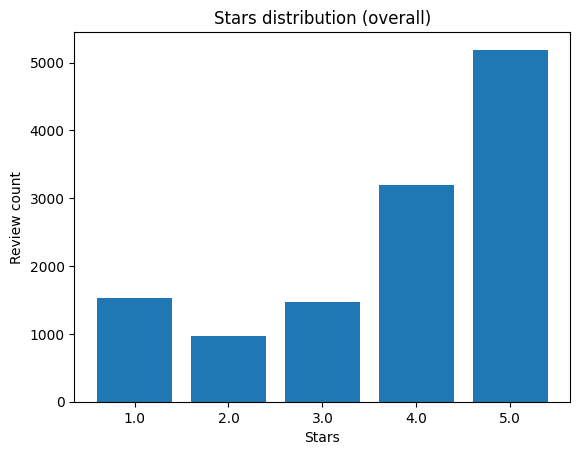

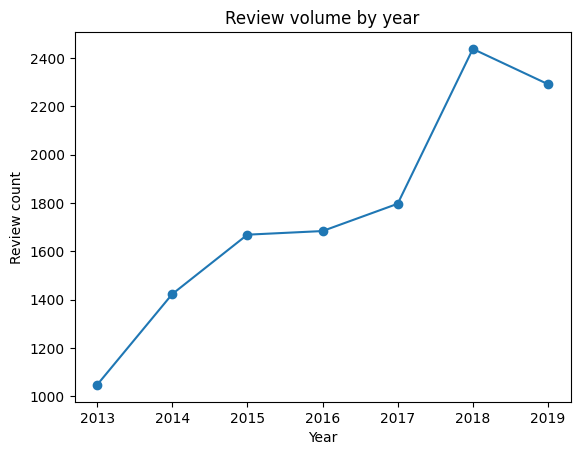


Year summary:
   year  n_reviews  avg_stars  pct_1_2  pct_4_5
0  2013       1047      3.797    15.57    68.96
1  2014       1423      3.793    17.50    69.01
2  2015       1669      3.778    18.21    68.42
3  2016       1684      3.825    19.06    69.06
4  2017       1797      3.794    19.81    68.78
5  2018       2438      3.742    22.48    66.37
6  2019       2292      3.731    24.04    66.54


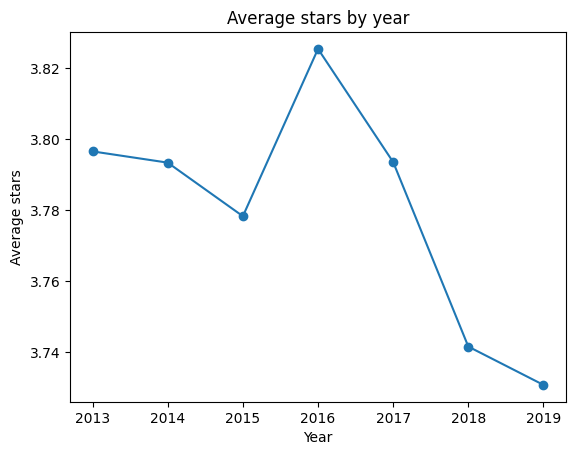


Season summary:
   season  n_reviews  avg_stars  pct_1_2  avg_words
0  Summer       7296      3.769    20.34       95.0
1  Winter       5054      3.782    19.94       98.1

Top 10 venues by review volume:
                        name  n_reviews  avg_stars
52             Loveless Cafe       1178      4.286
32   Tootsie's Orchid Lounge        470      3.602
50       Rippy's Bar & Grill        442      3.179
121   Robert's Western World        439      4.412
74        Honky Tonk Central        365      3.342
0             Grand Ole Opry        322      4.401
111         Wildhorse Saloon        303      3.429
29       Listening Room Cafe        302      3.762
73        Sambuca Restaurant        300      3.963
17         Bavarian Bierhaus        297      3.791

Best 10 venues (min 50 reviews):
                       name  n_reviews  avg_stars
138          Plaza Mariachi         71      4.690
25       Nashville Symphony         50      4.680
84          The Station Inn         86      4.663

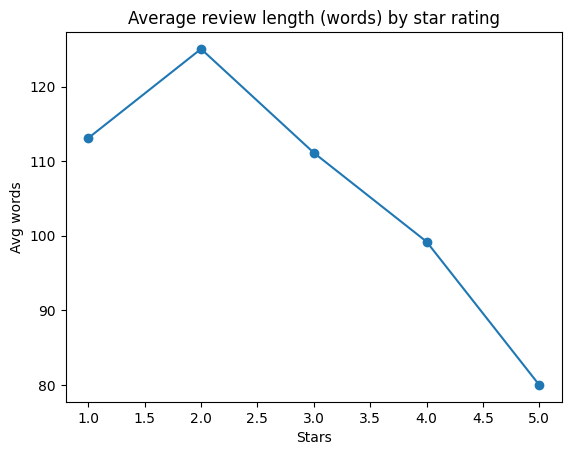

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

PATH = "../Data/nashville_music_venues_summer_winter_reviews_2013_2019.csv"
df = pd.read_csv(PATH)

df["date"] = pd.to_datetime(df["date"], errors="coerce")
df["text_len_words"] = df["text"].astype(str).str.split().str.len()

# -------------------------
# 1) Basic dataset summary
# -------------------------
print("Shape:", df.shape)
print("Unique review_id:", df["review_id"].nunique())
print("Unique business_id:", df["business_id"].nunique())
print("Unique user_id:", df["user_id"].nunique())
print("Date range:", df["date"].min(), "to", df["date"].max())

missing = (df.isna().mean() * 100).sort_values(ascending=False)
print("\nTop missingness (%):")
print(missing.head(10))

print("\nDuplicate rows:", df.duplicated().sum())
print("Duplicate review_id:", df["review_id"].duplicated().sum())

# -------------------------
# 2) Stars distribution
# -------------------------
stars_counts = df["stars"].value_counts().sort_index()
stars_pct = (stars_counts / len(df) * 100).round(2)

stars_table = pd.DataFrame({"count": stars_counts, "pct": stars_pct})
print("\nStars distribution:")
print(stars_table)

plt.figure()
plt.bar(stars_counts.index.astype(str), stars_counts.values)
plt.title("Stars distribution (overall)")
plt.xlabel("Stars")
plt.ylabel("Review count")
plt.show()

# -------------------------
# 3) Year distribution
# -------------------------
year_counts = df["year"].value_counts().sort_index()

plt.figure()
plt.plot(year_counts.index, year_counts.values, marker="o")
plt.title("Review volume by year")
plt.xlabel("Year")
plt.ylabel("Review count")
plt.show()

# Avg stars and low-star share by year
year_summary = (
    df.groupby("year")
      .agg(
          n_reviews=("review_id", "count"),
          avg_stars=("stars", "mean"),
          pct_1_2=("stars", lambda s: s.isin([1,2]).mean() * 100),
          pct_4_5=("stars", lambda s: s.isin([4,5]).mean() * 100),
      )
      .reset_index()
      .sort_values("year")
)

print("\nYear summary:")
print(year_summary.round({"avg_stars": 3, "pct_1_2": 2, "pct_4_5": 2}))

plt.figure()
plt.plot(year_summary["year"], year_summary["avg_stars"], marker="o")
plt.title("Average stars by year")
plt.xlabel("Year")
plt.ylabel("Average stars")
plt.show()

# -------------------------
# 4) Season comparison
# -------------------------
season_summary = (
    df.groupby("season")
      .agg(
          n_reviews=("review_id", "count"),
          avg_stars=("stars", "mean"),
          pct_1_2=("stars", lambda s: s.isin([1,2]).mean() * 100),
          avg_words=("text_len_words", "mean"),
      )
      .reset_index()
)

print("\nSeason summary:")
print(season_summary.round({"avg_stars": 3, "pct_1_2": 2, "avg_words": 1}))

# -------------------------
# 5) Venue-level aggregation
# -------------------------
venue_stats = (
    df.groupby(["business_id", "name"], as_index=False)
      .agg(
          n_reviews=("review_id", "count"),
          avg_stars=("stars", "mean"),
          median_stars=("stars", "median"),
          business_review_count=("review_count", "max"),
          latitude=("latitude", "first"),
          longitude=("longitude", "first"),
          postal_code=("postal_code", "first"),
      )
)

top10_volume = venue_stats.sort_values("n_reviews", ascending=False).head(10)
print("\nTop 10 venues by review volume:")
print(top10_volume[["name", "n_reviews", "avg_stars"]].round({"avg_stars": 3}))

min_n = 50
best10 = venue_stats[venue_stats["n_reviews"] >= min_n].sort_values(
    ["avg_stars", "n_reviews"], ascending=[False, False]
).head(10)

worst10 = venue_stats[venue_stats["n_reviews"] >= min_n].sort_values(
    ["avg_stars", "n_reviews"], ascending=[True, False]
).head(10)

print(f"\nBest 10 venues (min {min_n} reviews):")
print(best10[["name", "n_reviews", "avg_stars"]].round({"avg_stars": 3}))

print(f"\nWorst 10 venues (min {min_n} reviews):")
print(worst10[["name", "n_reviews", "avg_stars"]].round({"avg_stars": 3}))

# -------------------------
# 6) Text length vs stars
# -------------------------
len_by_stars = (
    df.groupby("stars")
      .agg(
          n=("review_id", "count"),
          avg_words=("text_len_words", "mean"),
          median_words=("text_len_words", "median"),
      )
      .reset_index()
      .sort_values("stars")
)

print("\nText length by stars:")
print(len_by_stars.round({"avg_words": 1, "median_words": 1}))

plt.figure()
plt.plot(len_by_stars["stars"], len_by_stars["avg_words"], marker="o")
plt.title("Average review length (words) by star rating")
plt.xlabel("Stars")
plt.ylabel("Avg words")
plt.show()